# ✅ ŘEŠENÍ: Notebook 01 — Průzkum a příprava dat

> **Otevři toto řešení až po vlastním pokusu v `01_pruzkum_dat_ULOHY.ipynb`!**

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)
print('Setup hotový!')

Setup hotový!


### Řešení Úlohy 1: Načtení EKC datasetu


In [2]:
forest_ekc = pd.read_csv('../../data_dan/forest_ekc_model.csv')
print(f'Počet zemí: {forest_ekc.shape[0]}')
print(f'Počet sloupců: {forest_ekc.shape[1]}')
print(f'Sloupce: {forest_ekc.columns.tolist()}')
forest_ekc.head(5)

Počet zemí: 211
Počet sloupců: 5
Sloupce: ['Country', 'Code', 'Forest_1990', 'Forest_2025', 'Forest_change']


,Country,Code,Forest_1990,Forest_2025,Forest_change
0,Afghanistan,AFG,1.850,1.850,0.000
1,Albania,ALB,28.790,34.340,5.550
2,Algeria,DZA,0.720,0.710,-0.010
3,American Samoa,ASM,90.350,79.250,-11.100
4,Andorra,AND,37.640,38.770,1.130


### Řešení Úlohy 2: Průzkum dat


In [3]:
print(forest_ekc.info())
print('\nChybějící hodnoty:')
print(forest_ekc.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 211 entries, 0 to 210
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Country        211 non-null    str    
 1   Code           201 non-null    str    
 2   Forest_1990    211 non-null    float64
 3   Forest_2025    211 non-null    float64
 4   Forest_change  211 non-null    float64
dtypes: float64(3), str(2)
memory usage: 8.4 KB
None

Chybějící hodnoty:
Country           0
Code             10
Forest_1990       0
Forest_2025       0
Forest_change     0
dtype: int64


In [4]:
forest_ekc.describe()

,Forest_1990,Forest_2025,Forest_change
count,211.000,211.000,211.000
mean,34.184,32.975,-1.209
std,25.779,24.393,7.044
min,0.000,0.000,-34.110
25%,11.620,11.820,-2.865
50%,29.910,32.990,0.000
75%,53.460,51.500,1.695
max,96.230,93.360,17.280


In [5]:
zalesnovani = (forest_ekc['Forest_change'] > 0).sum()
odlesnovani = (forest_ekc['Forest_change'] < 0).sum()
bez_zmeny   = (forest_ekc['Forest_change'] == 0).sum()
print(f'Zalesňující: {zalesnovani}')
print(f'Odlesňující: {odlesnovani}')
print(f'Bez změny:   {bez_zmeny}')

Zalesňující: 90
Odlesňující: 91
Bez změny:   30


### Řešení Úlohy 3: HDP data


In [6]:
forest_gdp = pd.read_csv('../../data_dan/MAIN_Forest_GDP_joined.csv')
forest_gdp = forest_gdp.rename(columns={
    'Share of land covered by forest': 'forest_pct',
    'GDP per capita (current US$)': 'gdp_per_capita',
    'Share of land covered by forest (Annotations)': 'forest_annotations'
})
forest_gdp_filtered = forest_gdp[forest_gdp['Year'] >= 1990].copy()

mean_gdp = (
    forest_gdp_filtered
    .groupby(['Entity', 'Code'])['gdp_per_capita']
    .mean()
    .reset_index()
    .rename(columns={'gdp_per_capita': 'mean_gdp', 'Entity': 'Country'})
)
print(f'Průměrné HDP pro {len(mean_gdp)} zemí')
print(f'Chybějící: {mean_gdp["mean_gdp"].isnull().sum()}')

Průměrné HDP pro 214 zemí
Chybějící: 6


---
## Část 3b: Vývoj lesního pokryvu v čase (časová řada)

Panelová data v `MAIN_Forest_GDP_joined.csv` nám umožňují vidět **trend přes roky** — nejen snapshot 1990 vs. 2025.
Průměrný % lesního pokryvu **všech zemí** nám řekne, jestli celkový trend jde k zalesnění nebo odlesnění.

Roky v datech: 1990 – 2025

Průměrný % lesa (vybrané roky):
  1990: 34.25%
  2000: 33.93%
  2010: 33.82%
  2020: 33.42%
  2024: 33.28%


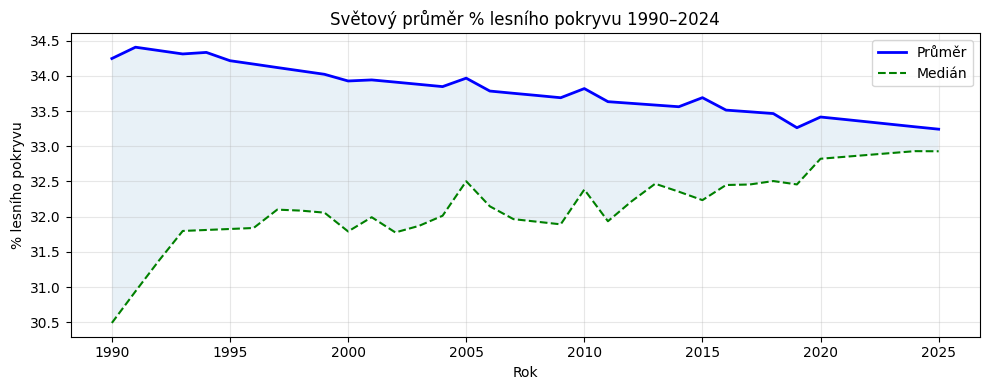


➡️  Pokud průměr klesá, globálně přichází o les. Pokud roste, globálně zalesňujeme.


In [7]:
# Průměrný % lesního pokryvu podle roku — jak se vyvíjel svět jako celek?
yearly_forest = (
    forest_gdp_filtered
    .groupby('Year')['forest_pct']
    .agg(mean='mean', median='median', count='count')
    .reset_index()
    .round(3)
)

print(f'Roky v datech: {yearly_forest["Year"].min()} – {yearly_forest["Year"].max()}')
print(f'\nPrůměrný % lesa (vybrané roky):')
for yr in [1990, 2000, 2010, 2020, 2024]:
    row = yearly_forest[yearly_forest['Year'] == yr]
    if len(row):
        print(f'  {yr}: {row.iloc[0]["mean"]:.2f}%')

# Čárový graf vývoje v čase
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(yearly_forest['Year'], yearly_forest['mean'], 'b-', linewidth=2, label='Průměr')
ax.plot(yearly_forest['Year'], yearly_forest['median'], 'g--', linewidth=1.5, label='Medián')
ax.fill_between(yearly_forest['Year'], yearly_forest['mean'], yearly_forest['median'], alpha=0.1)
ax.set_xlabel('Rok')
ax.set_ylabel('% lesního pokryvu')
ax.set_title('Světový průměr % lesního pokryvu 1990–2024')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print('\n➡️  Pokud průměr klesá, globálně přichází o les. Pokud roste, globálně zalesňujeme.')

---
## Část 3c: Skutečné globální % lesa — vážený průměr (Úloha 3d)

Nevážený průměr výše dává každé zemi stejnou váhu bez ohledu na rozlohu. Soubor `Forest area compared to total area.csv` obsahuje absolutní plochy, ze kterých spočítáme **skutečné globální procento**.

> 📌 Soubor má dvouřádkové záhlaví (řádek 0 = typ dat, řádek 1 = rok) → `header=[0, 1]`.

In [ ]:
# Úloha 3d: Skutečné globální % lesa vážené rozlohou zemí
fa = pd.read_csv('../../data_raw/Forest area compared to total area.csv',
                 header=[0, 1], index_col=0)

roky = ['1990', '2000', '2010', '2015', '2020', '2025']
weighted_results = {}

print('Skutečný vážený průměr lesního pokryvu:')
for rok in roky:
    forest_sum = fa['Forest (1 000 ha)'][rok].dropna().sum()
    land_sum   = fa['Total land area (1 000 ha)'][rok].dropna().sum()
    weighted_results[rok] = forest_sum / land_sum * 100
    print(f'{rok}: {weighted_results[rok]:.2f}%')

# Srovnání s nevážným průměrem per-country (z forest_ekc)
unweighted_1990 = forest_ekc['Forest_1990'].mean()
unweighted_2025 = forest_ekc['Forest_2025'].mean()
print(f'\nSrovnání s nevážným průměrem per-country:')
print(f'  1990: nevážený {unweighted_1990:.2f}% vs. vážený {weighted_results["1990"]:.2f}% → {weighted_results["1990"]-unweighted_1990:+.2f} pp')
print(f'  2025: nevážený {unweighted_2025:.2f}% vs. vážený {weighted_results["2025"]:.2f}% → {weighted_results["2025"]-unweighted_2025:+.2f} pp')

### Řešení Úlohy 4: Klasifikace Světové banky


In [8]:
wb_raw = pd.read_csv('../../data_raw/2025_World_Bank_classification_by_Income.csv', skiprows=2)
wb_class = wb_raw[['Code', 'Region', 'Income group']].copy()
wb_class.columns = ['code', 'region', 'income_group']
wb_class = wb_class.dropna(subset=['code', 'income_group'])
# World Bank file obsahuje i agregátní záznamy (Sub-Saharan Africa, World, atd.)
# Ponecháme pouze záznamy s validním ISO3 kódem (přesně 3 velká písmena)
wb_class = wb_class[wb_class['code'].str.match(r'^[A-Z]{3}$', na=False)]
print(f'Počet zemí: {len(wb_class)}')
print(wb_class['income_group'].value_counts())

Počet zemí: 218
income_group
High income            86
Upper middle income    55
Lower middle income    51
Low income             26
Name: count, dtype: int64


### Řešení Úlohy 5: Merge


In [9]:
ekc_master = pd.merge(forest_ekc, mean_gdp[['Code', 'mean_gdp']], on='Code', how='left')
ekc_master = pd.merge(ekc_master, wb_class, left_on='Code', right_on='code', how='left')

if 'code' in ekc_master.columns:
    ekc_master = ekc_master.drop(columns=['code'])

ekc_master = ekc_master.rename(columns={
    'Country': 'country', 'Code': 'code',
    'Forest_1990': 'forest_1990', 'Forest_2025': 'forest_2025', 'Forest_change': 'forest_change'
})

ekc_complete = ekc_master.dropna(subset=['forest_change', 'mean_gdp', 'income_group']).copy()
ekc_complete['log_gdp'] = np.log(ekc_complete['mean_gdp'])

print(f'Kompletní záznamy: {len(ekc_complete)} zemí')
ekc_complete.head(3)

Kompletní záznamy: 199 zemí


,country,code,forest_1990,forest_2025,forest_change,mean_gdp,region,income_group,log_gdp
0,Afghanistan,AFG,1.850,1.850,0.000,415.495,South Asia,Low income,6.029
1,Albania,ALB,28.790,34.340,5.550,3520.932,Europe & Central Asia,Upper middle income,8.166
2,Algeria,DZA,0.720,0.710,-0.010,3545.599,Middle East & North Africa,Upper middle income,8.173


---
## ✔️ Sanity Check — Ověření správnosti dat

Před analýzou vždy zkontrolujeme, že merge dopadl správně.
Vybereme několik konkrétních zemí a ověříme, že hodnoty dávají smysl.

In [10]:
# Ověření: Jsou klíčové země v datasetu se správnými hodnotami?
test_codes = ['CZE', 'BRA', 'ETH', 'DEU', 'IDN']
print('=== SANITY CHECK ===')
for code in test_codes:
    row = ekc_complete[ekc_complete['code'] == code]
    if len(row) == 0:
        print(f'CHYBA: {code} nenalezen! Zkontroluj merge.')
    else:
        r = row.iloc[0]
        print(f'{code} ({r["country"]:20s}) | income: {str(r.get("income_group","?")):<22} | '
              f'forest_change: {r["forest_change"]:+6.2f}% | HDP: ${r["mean_gdp"]:>9,.0f}')

# Očekávané hodnoty (přibližně):
# CZE (Czech Republic) → High income, forest mírně kladný
# BRA (Brazil)         → Upper middle income, velká plocha lesa
# ETH (Ethiopia)       → Low income, malé HDP
# DEU (Germany)        → High income, stabilní les
# IDN (Indonesia)      → Lower middle income, odlesnění

n_high = (ekc_complete['income_group'] == 'High income').sum()
n_low  = (ekc_complete['income_group'] == 'Low income').sum()
print(f'\nHigh income zemí: {n_high} | Low income zemí: {n_low}')
if n_high == 0 or n_low == 0:
    print('POZOR: Některá příjmová skupina má 0 zemí — problém s merging!')
else:
    print('Rozložení příjmových skupin vypadá v pořádku.')

=== SANITY CHECK ===
CZE (Czechia             ) | income: High income            | forest_change:  +1.67% | HDP: $   15,242
BRA (Brazil              ) | income: Upper middle income    | forest_change: -15.83% | HDP: $    6,916
ETH (Ethiopia            ) | income: Low income             | forest_change:  -1.59% | HDP: $      403
DEU (Germany             ) | income: High income            | forest_change:  +0.52% | HDP: $   37,996
IDN (Indonesia           ) | income: Upper middle income    | forest_change: -10.76% | HDP: $    2,284

High income zemí: 75 | Low income zemí: 25
Rozložení příjmových skupin vypadá v pořádku.


### Řešení Úlohy 6: Průměrná změna lesa podle skupin


In [11]:
income_order = ['Low income', 'Lower middle income', 'Upper middle income', 'High income']
income_summary = (
    ekc_complete
    .groupby('income_group')['forest_change']
    .agg(['mean', 'median', 'std', 'count'])
    .reindex(income_order)
    .round(3)
)
income_summary.columns = ['Průměr', 'Medián', 'Std', 'Počet zemí']
income_summary

,Průměr,Medián,Std,Počet zemí
income_group,,,,
Low income,-5.547,-2.880,7.005,25
Lower middle income,-3.911,-1.140,8.631,47
Upper middle income,-0.608,0.000,7.406,52
High income,1.383,0.790,4.287,75


### Řešení Úlohy 7: Export


In [12]:
os.makedirs('../output', exist_ok=True)
ekc_complete.to_csv('../output/ekc_analysis.csv', index=False, encoding='utf-8-sig')
print(f'✅ Uloženo: ../output/ekc_analysis.csv ({len(ekc_complete)} řádků)')

✅ Uloženo: ../output/ekc_analysis.csv (199 řádků)
